# Modelling

### Import Library Deep Learning

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Pustaka Deep Learning Berhasil Dimuat!")
print("TensorFlow Version:", tf.__version__)

I0000 00:00:1786564520.627369   65640 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786564520.627997   65640 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786564520.688881   65640 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786564523.744179   65640 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

✓ Pustaka Deep Learning Berhasil Dimuat!
TensorFlow Version: 2.21.0


### Memuat Data Hasil Ekstraksi

In [2]:
# Tentukan path lokasi folder tempat menyimpan file .npy
DATA_DIR = '../hasil_data_preparation/rasio_80_20'

# Load array koordinat spasio-temporal 3D
X_train = np.load(os.path.join(DATA_DIR, 'X_train_coor.npy'))
Y_train = np.load(os.path.join(DATA_DIR, 'Y_train_coor.npy'))
X_val = np.load(os.path.join(DATA_DIR, 'X_val_coor.npy'))
Y_val = np.load(os.path.join(DATA_DIR, 'Y_val_coor.npy'))

# Transformasi label integer (0-25) menjadi matriks biner One-Hot Encoding
num_classes = 26
Y_train_encoded = tf.keras.utils.to_categorical(Y_train, num_classes=num_classes)
Y_val_encoded = tf.keras.utils.to_categorical(Y_val, num_classes=num_classes)

print("=== VERIFIKASI DIMENSI MATRIKS UTAMA ===")
print(f"Shape X Latih      : {X_train.shape}")
print(f"Shape Y Latih Target: {Y_train_encoded.shape}")
print(f"\nShape X Validasi   : {X_val.shape}")
print(f"Shape Y Val Target : {Y_val_encoded.shape}")

=== VERIFIKASI DIMENSI MATRIKS UTAMA ===
Shape X Latih      : (3744, 30, 63)
Shape Y Latih Target: (3744, 26)

Shape X Validasi   : (936, 30, 63)
Shape Y Val Target : (936, 26)


### Perancangan Arsitektur Hybrid CRNN Spatio-Temporal

In [3]:
# ==========================================================
# 3.4.1.3 PERANCANGAN ARSITEKTUR HYBRID CRNN
# ==========================================================

def build_sibi_crnn(input_shape=(30, 63), num_classes=26):
    model = Sequential([
        
        # INPUT LAYER
        tf.keras.Input(shape=input_shape),

        # ==================================================
        # SPATIAL FEATURE EXTRACTION BLOCK (CONV1D)
        # ==================================================
        Conv1D(
            filters=64,
            kernel_size=3,
            activation='relu',
            padding='same'
        ),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(
            filters=128,
            kernel_size=3,
            activation='relu',
            padding='same'
        ),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # ==================================================
        # TEMPORAL FEATURE EXTRACTION BLOCK (LSTM)
        # ==================================================
        LSTM(
            units=128,
            return_sequences=False
        ),
        Dropout(0.3),

        # ==================================================
        # CLASSIFIER BLOCK
        # ==================================================
        Dense(
            units=64,
            activation='relu'
        ),
        BatchNormalization(),
        Dropout(0.3),

        Dense(
            units=num_classes,
            activation='softmax'
        )
    ])

    return model


# Inisialisasi model CRNN
sibi_model = build_sibi_crnn(
    input_shape=(30, 63),
    num_classes=26
)

print("✓ Arsitektur Hybrid CRNN berhasil dibangun")

✓ Arsitektur Hybrid CRNN berhasil dibangun


E0000 00:00:1786564533.097100   65640 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### Konfigurasi Kompilasi Model

In [4]:
# ==========================================================
# 3.4.1.4 KONFIGURASI KOMPILASI MODEL
# ==========================================================

sibi_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model berhasil dikompilasi")
print("Optimizer      : Adam")
print("Learning Rate  : 0.001")
print("Loss Function  : categorical_crossentropy")
print("Metric         : accuracy")

✓ Model berhasil dikompilasi
Optimizer      : Adam
Learning Rate  : 0.001
Loss Function  : categorical_crossentropy
Metric         : accuracy


### Verifikasi Struktur Arsitektur Model

In [5]:
# ==========================================================
# 3.4.1.5 VERIFIKASI STRUKTUR ARSITEKTUR MODEL
# ==========================================================

print("======================================")
print(" RINGKASAN ARSITEKTUR HYBRID CRNN ")
print("======================================\n")

sibi_model.summary()

 RINGKASAN ARSITEKTUR HYBRID CRNN 



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │        12,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,418 (700.85 KB)

 Trainable params: 178,906 (698.85 KB)

 Non-trainable params: 512 (2.00 KB)

### Konfigurasi Strategi Pelatihan Model

In [6]:
# ==========================================================
# 3.4.1.6 KONFIGURASI STRATEGI PELATIHAN MODEL
# ==========================================================

# Lokasi penyimpanan model terbaik
checkpoint_path = "hasil_modelling/rasio_80_20/best_sibi_crnn_model.keras"

callbacks_list = [

    # Menghentikan training ketika val_loss stagnan
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    # Menurunkan learning rate secara otomatis
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Menyimpan model terbaik
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("✓ Strategi pelatihan model berhasil dikonfigurasi")
print("✓ EarlyStopping aktif")
print("✓ ReduceLROnPlateau aktif")
print("✓ ModelCheckpoint aktif")

✓ Strategi pelatihan model berhasil dikonfigurasi
✓ EarlyStopping aktif
✓ ReduceLROnPlateau aktif
✓ ModelCheckpoint aktif


### Pelatihan Model Hybrid CRNN

In [7]:
# ==========================================================
# 3.4.1.7 PELATIHAN MODEL HYBRID CRNN
# ==========================================================

EPOCHS = 100
BATCH_SIZE = 64

print("=========================================")
print(" MEMULAI PROSES PELATIHAN MODEL CRNN ")
print("=========================================\n")

history = sibi_model.fit(
    X_train,
    Y_train_encoded,
    validation_data=(
        X_val,
        Y_val_encoded
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    shuffle=True,
    verbose=1
)

print("\n✓ Proses pelatihan model selesai")

 MEMULAI PROSES PELATIHAN MODEL CRNN 

Epoch 1/100
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3267 - loss: 2.4107
Epoch 1: val_accuracy improved from None to 0.41346, saving model to hasil_modelling/rasio_80_20/best_sibi_crnn_model.keras

Epoch 1: finished saving model to hasil_modelling/rasio_80_20/best_sibi_crnn_model.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.5521 - loss: 1.5993 - val_accuracy: 0.4135 - val_loss: 2.9565 - learning_rate: 0.0010
Epoch 2/100
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8119 - loss: 0.6613
Epoch 2: val_accuracy did not improve from 0.41346
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8339 - loss: 0.5672 - val_accuracy: 0.2051 - val_loss: 2.9212 - learning_rate: 0.0010
Epoch 3/100
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8689 - loss: 0.4366
Epoch 3: val_accuracy did not improve from 0.41346
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8713 - loss: 0.4090 - val_accuracy: 0.1806 - val_loss

# Evaluasi Model

## Evaluasi Kuantitatif

### Grafik Performa Accuracy Curve

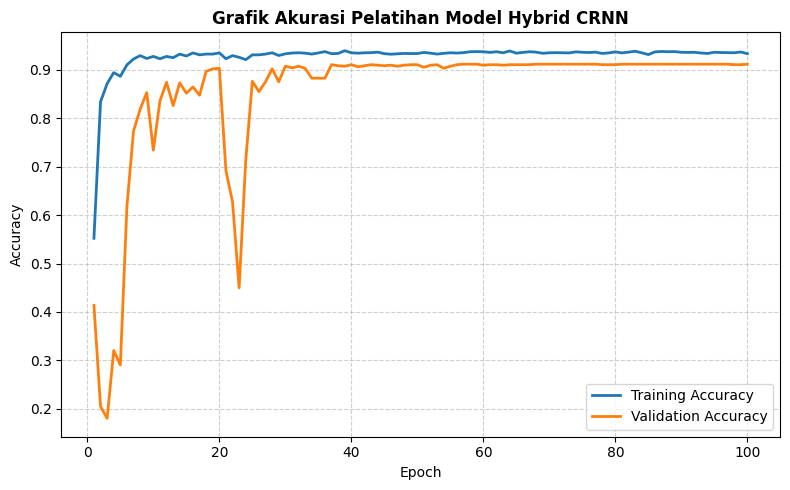

✓ Grafik Accuracy tersimpan pada: hasil_modelling/rasio_80_20/grafik_accuracy_crnn.png


In [8]:
import os
import matplotlib.pyplot as plt

# Pastikan folder tersedia
os.makedirs("hasil_modelling/rasio_80_20", exist_ok=True)

# Ambil histori akurasi
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(1, len(acc) + 1)

# ==========================================================
# GRAFIK ACCURACY
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    acc,
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    epochs_range,
    val_acc,
    label='Validation Accuracy',
    linewidth=2
)

plt.title(
    'Grafik Akurasi Pelatihan Model Hybrid CRNN',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.grid(
    True,
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

# Simpan gambar
file_acc = "hasil_modelling/rasio_80_20/grafik_accuracy_crnn.png"

plt.savefig(
    file_acc,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"✓ Grafik Accuracy tersimpan pada: {file_acc}")

### Grafik Performa Loss Curve

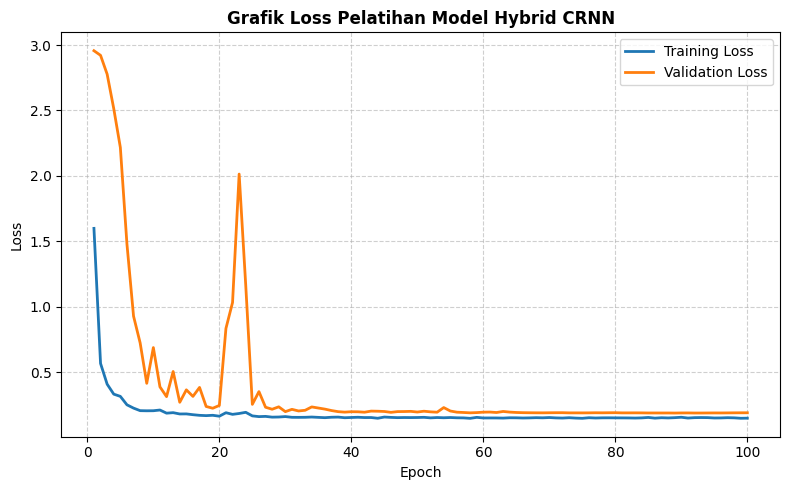

✓ Grafik Loss tersimpan pada: hasil_modelling/rasio_80_20/grafik_loss_crnn.png


In [9]:
import os
import matplotlib.pyplot as plt

# Pastikan folder tersedia
os.makedirs("hasil_modelling/rasio_80_20", exist_ok=True)

# Ambil histori loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(loss) + 1)

# ==========================================================
# GRAFIK LOSS
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    loss,
    label='Training Loss',
    linewidth=2
)

plt.plot(
    epochs_range,
    val_loss,
    label='Validation Loss',
    linewidth=2
)

plt.title(
    'Grafik Loss Pelatihan Model Hybrid CRNN',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.grid(
    True,
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

# Simpan gambar
file_loss = "hasil_modelling/rasio_80_20/grafik_loss_crnn.png"

plt.savefig(
    file_loss,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"✓ Grafik Loss tersimpan pada: {file_loss}")

## Evaluasi Performa Klasifikasi

In [10]:
# ==========================================================
# PERSIAPAN HASIL PREDIKSI MODEL
# ==========================================================

Y_pred_prob = sibi_model.predict(X_val)

Y_pred_labels = np.argmax(
    Y_pred_prob,
    axis=1
)

target_names = [
    chr(i) for i in range(65, 91)
]

print("✓ Hasil prediksi model berhasil dibuat")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
✓ Hasil prediksi model berhasil dibuat


### Overall Accuracy

In [11]:
from sklearn.metrics import accuracy_score

overall_accuracy = accuracy_score(
    Y_val,
    Y_pred_labels
)

print("===================================")
print(" OVERALL ACCURACY MODEL HYBRID CRNN ")
print("===================================")

print(f"Overall Accuracy : {overall_accuracy:.4f}")
print(f"Overall Accuracy : {overall_accuracy*100:.2f}%")

 OVERALL ACCURACY MODEL HYBRID CRNN 
Overall Accuracy : 0.9113
Overall Accuracy : 91.13%


### Classification Report

In [12]:
print("=======================================================")
# Laporan Evaluasi Klasifikasi Multi-Kelas Spatio-Temporal
print("      CLASSIFICATION REPORT MODEL HYBRID CRNN SIBI     ")
print("=======================================================\n")

print(
    classification_report(
        Y_val,
        Y_pred_labels,
        target_names=target_names
    )
)

      CLASSIFICATION REPORT MODEL HYBRID CRNN SIBI     

              precision    recall  f1-score   support

           A       1.00      0.89      0.94        36
           B       1.00      1.00      1.00        36
           C       0.97      0.83      0.90        36
           D       1.00      1.00      1.00        36
           E       1.00      1.00      1.00        36
           F       1.00      1.00      1.00        36
           G       0.30      0.97      0.46        36
           H       1.00      1.00      1.00        36
           I       1.00      1.00      1.00        36
           J       1.00      1.00      1.00        36
           K       1.00      1.00      1.00        36
           L       1.00      1.00      1.00        36
           M       0.00      0.00      0.00        36
           N       0.00      0.00      0.00        36
           O       1.00      1.00      1.00        36
           P       1.00      1.00      1.00        36
           Q       1.00 

/home/zacx/Downloads/SKRIPSI/Aplikasi/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zacx/Downloads/SKRIPSI/Aplikasi/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zacx/Downloads/SKRIPSI/Aplikasi/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

### Bar Chart F1-Score CRNN

/home/zacx/Downloads/SKRIPSI/Aplikasi/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zacx/Downloads/SKRIPSI/Aplikasi/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zacx/Downloads/SKRIPSI/Aplikasi/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

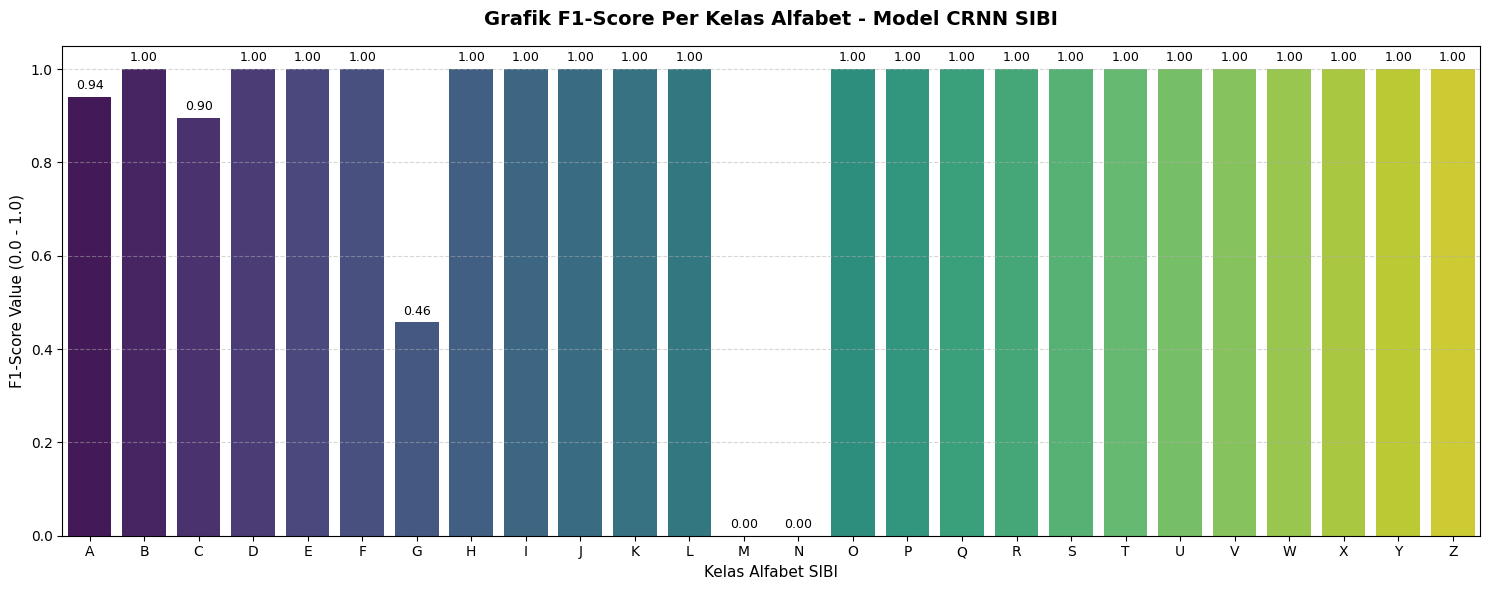

✓ Grafik batang F1-Score berhasil disimpan di 'hasil_modelling/rasio_80_20/crnn_f1_score_chart.png'


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. Ambil data report dalam bentuk dictionary (bukan string teks)
report_dict = classification_report(Y_val, Y_pred_labels, target_names=target_names, output_dict=True)

# 2. Ubah menjadi DataFrame pandas dan buang baris rangkuman (accuracy, macro avg, weighted avg)
df_report = pd.DataFrame(report_dict).transpose()
df_classes_only = df_report.loc[target_names] # Hanya mengambil baris A-Z

# 3. Plotting F1-Score tiap kelas menggunakan Bar Chart
plt.figure(figsize=(15, 6))
sns.barplot(
    x=df_classes_only.index, 
    y=df_classes_only['f1-score'], 
    palette='viridis'
)

plt.title('Grafik F1-Score Per Kelas Alfabet - Model CRNN SIBI', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kelas Alfabet SIBI', fontsize=11)
plt.ylabel('F1-Score Value (0.0 - 1.0)', fontsize=11)
plt.ylim(0, 1.05) # Batas atas grafik
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tambahkan label nilai di atas setiap batang grafik
for i, val in enumerate(df_classes_only['f1-score']):
    plt.text(i, val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Simpan gambar ke folder hasil_modelling
plt.savefig("hasil_modelling/rasio_80_20/crnn_f1_score_chart.png", dpi=300)
plt.show()

print("✓ Grafik batang F1-Score berhasil disimpan di 'hasil_modelling/rasio_80_20/crnn_f1_score_chart.png'")

### Confusion Matrix

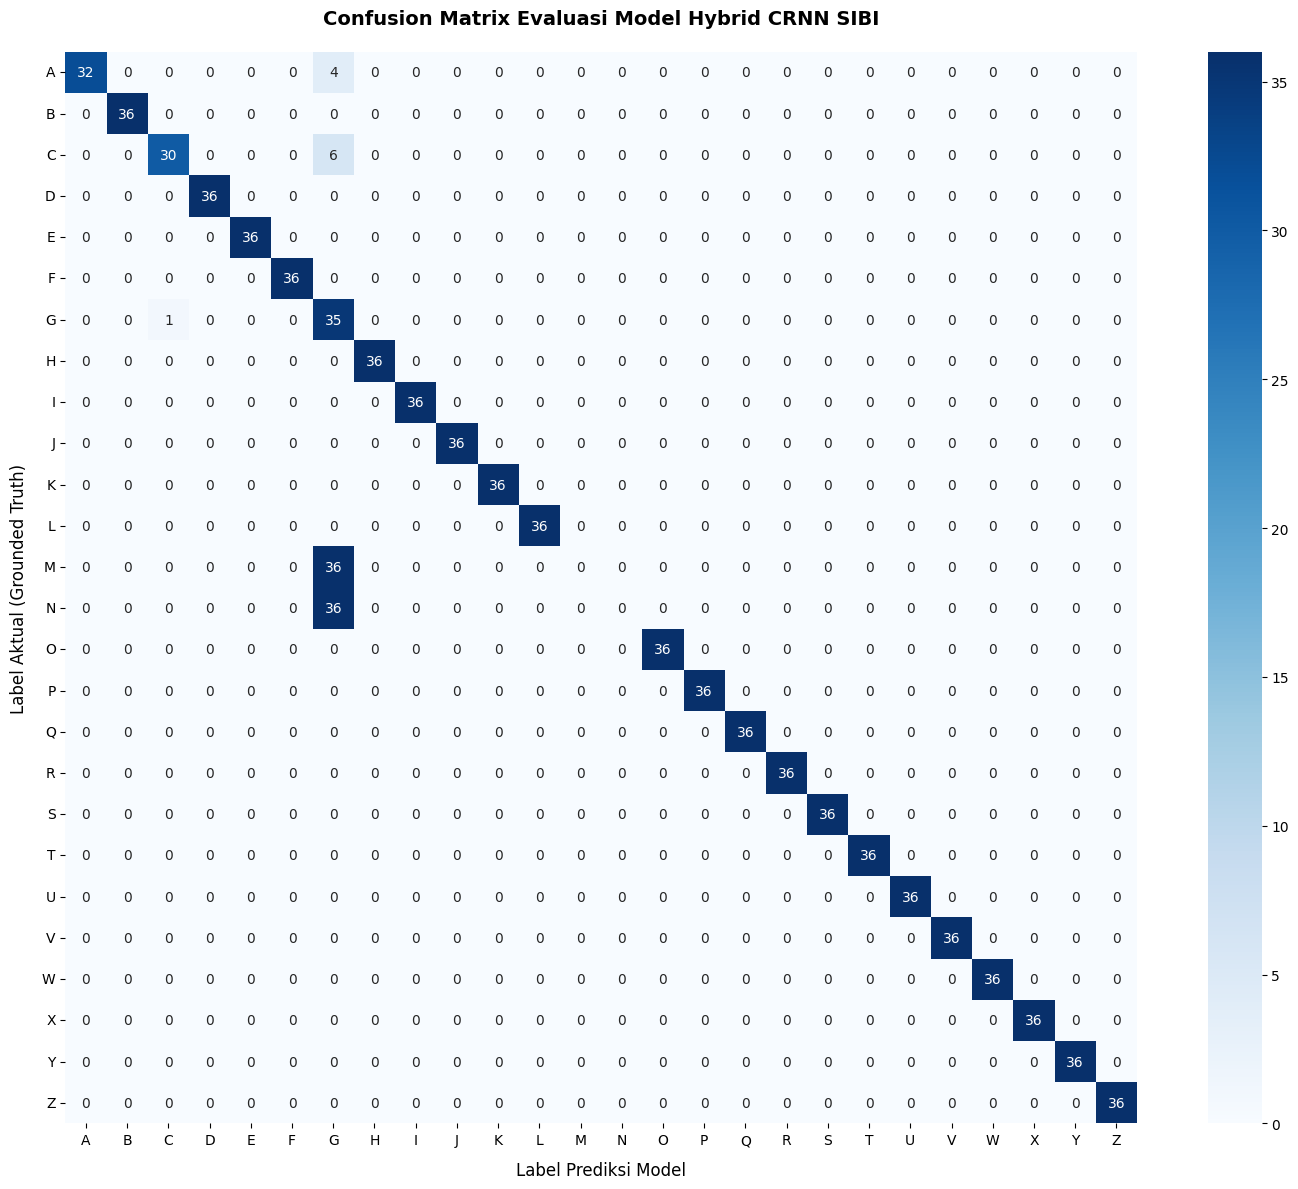

✓ Grafik Confusion Matrix Berhasil Digambar dan Disimpan dengan nama 'confusion_matrix_sibi.png'!


In [14]:
# 1. Hitung Confusion Matrix
cm = confusion_matrix(Y_val, Y_pred_labels)

# 2. Atur ukuran grafis gambar
plt.figure(figsize=(15, 12))

# 3. Gambar Heatmap menggunakan Seaborn
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=target_names, 
    yticklabels=target_names,
    cbar=True,
    square=True
)

plt.title('Confusion Matrix Evaluasi Model Hybrid CRNN SIBI', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Label Prediksi Model', fontsize=12, labelpad=10)
plt.ylabel('Label Aktual (Grounded Truth)', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

# 4. Simpan gambar secara fisik untuk disisipkan langsung ke Ms. Word Bab IV
plt.savefig('hasil_modelling/rasio_80_20/confusion_matrix_sibi.png', dpi=300)
plt.show()

print("✓ Grafik Confusion Matrix Berhasil Digambar dan Disimpan dengan nama 'confusion_matrix_sibi.png'!")

# Pengujian

### Prototype Deteksi SIBI

In [16]:
import os
import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp

print("=== PROGRAM LIVE DEMO DETEKSI SIBI - CRNN (FIXED REAL-TIME) ===")

# 1. Muat Model Terbaik .keras
model_path = "hasil_modelling/rasio_80_20/best_sibi_crnn_model.keras"
if not os.path.exists(model_path):
    print(f" ERROR: File model '{model_path}' tidak ditemukan di folder ini!")
else:
    sibi_model = tf.keras.models.load_model(model_path)
    classes = [chr(i) for i in range(65, 91)] # ['A' s.d 'Z']
    print("✓ Model CRNN Berhasil Dimuat.")

    # 2. Inisialisasi Hand Landmarker Detector
    base_options = mp.tasks.BaseOptions(model_asset_path='../hasil_data_preparation/hand_landmarker.task')
    options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=1,
        min_hand_detection_confidence=0.5
    )
    detector = mp.tasks.vision.HandLandmarker.create_from_options(options)
    print("✓ MediaPipe Hand Landmarker Berhasil Diinisialisasi.")

    # 3. Konfigurasi Menembak Langsung ke Hardware Utama (/dev/video0)
    cap = cv2.VideoCapture('/dev/video0', cv2.CAP_V4L2)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    frame_buffer = []
    predicted_letter = "Mencari Tangan..."
    confidence_score = 0.0

    print("\nMembuka Kamera... Tekan tombol 'q' pada JENDELA VIDEO untuk menutup Live Demo.")

    if not cap.isOpened():
        print(" ERROR: Gagal mengakses '/dev/video0'.")
        print("Buka terminal lalu jalankan perintah: sudo chmod 666 /dev/video0")
    else:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                print(" Koneksi kamera terputus atau frame kosong.")
                break
                
            frame = cv2.flip(frame, 1)
            h, w, c = frame.shape
            
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            
            # Deteksi Landmark koordinat oleh MediaPipe Tasks
            detection_result = detector.detect(mp_image)
            frame_features = [0.0] * 63
            
            if detection_result.hand_landmarks:
                hand_landmarks = detection_result.hand_landmarks[0]
                frame_features = []
                for lm in hand_landmarks:
                    frame_features.extend([lm.x, lm.y, lm.z])
                    cx, cy = int(lm.x * w), int(lm.y * h)
                    cv2.circle(frame, (cx, cy), 4, (0, 255, 0), -1)
                    
            frame_buffer.append(frame_features)
            
            if len(frame_buffer) > 30:
                frame_buffer.pop(0)
                
            # Prediksi Runtunan Waktu Spatio-Temporal jika buffer window (30 frame) sudah penuh
            if len(frame_buffer) == 30:
                input_tensor = np.array([frame_buffer], dtype=np.float32)
                preds = sibi_model.predict(input_tensor, verbose=0)
                idx = np.argmax(preds[0])
                predicted_letter = classes[idx]
                confidence_score = preds[0][idx] * 100

            # Gambar HUD Overlay Informasi Hasil Prediksi
            cv2.rectangle(frame, (10, 10), (350, 85), (0, 0, 0), -1)
            cv2.putText(frame, f"Prediksi Isyarat: {predicted_letter}", (20, 40), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2, cv2.LINE_AA)
            cv2.putText(frame, f"Presentase Ketepatan : {confidence_score:.2f}%", (20, 70), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
            
            # Tampilkan window aplikasi
            cv2.imshow("Live Demo Deteksi Bahasa Isyarat SIBI - CRNN", frame)
            
            # Berhenti jika menekan tombol 'q'
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        cap.release()
        cv2.destroyAllWindows()
        print("\n✓ Live Demo Pengujian Berhasil Ditutup Bersih.")

=== PROGRAM LIVE DEMO DETEKSI SIBI - CRNN (FIXED REAL-TIME) ===
✓ Model CRNN Berhasil Dimuat.


I0000 00:00:1786564965.234421   87261 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1786564965.241841   87275 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics (ICL GT1)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786564965.289502   87263 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786564965.323671   87265 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✓ MediaPipe Hand Landmarker Berhasil Diinisialisasi.

Membuka Kamera... Tekan tombol 'q' pada JENDELA VIDEO untuk menutup Live Demo.


W0000 00:00:1786564967.144202   87265 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
QFontDatabase: Cannot find font directory /home/zacx/Downloads/SKRIPSI/Aplikasi/env/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/zacx/Downloads/SKRIPSI/Aplikasi/env/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/zacx/Downloads/SKRIPSI/Aplikasi/env/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory


✓ Live Demo Pengujian Berhasil Ditutup Bersih.
